# Interactive Script for development

In [1]:
!which python

/dss/dsshome1/08/di38red/micromamba/envs/arosics/bin/python


### Tile extraction

In [36]:
catalog_url = 'https://earth-search.aws.element84.com/v1/'
catalog = pystacclient.open(catalog_url)

bbox_list= [100.767417,45.208589,100.783210,45.215543]
collection = 'sentinel-2-l1c'
bbox = bbox_list
start = '2020-08-29'
end = '2020-08-29'
results = catalog.search(
    bbox = bbox,
    collections=[collection],
    datetime=[start, end]
)
items = results.item_collection() #item_collection
print("%s items found" % len(items))

1 items found


In [37]:
items[0]

<Item id=S2A_21XVJ_20200829_2_L1C>

In [31]:
stac_json = items
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

In [32]:
gdf

,geometry,created,platform,constellation,instruments,eo:cloud_cover,proj:epsg,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,...,s2:datatake_type,s2:datastrip_id,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,processing:software,updated
0,"POLYGON ((-180 90, -180 -90, 180 -90, 180 90, ...",2024-03-02T12:32:08.668Z,sentinel-2a,sentinel-2,[msi],0.8059,32623,23,X,MJ,...,INS-NOBS,S2A_OPER_MSI_L1C_DS_MPS__20180904T225053_S2018...,S2A_OPER_MSI_L1C_TL_MPS__20180904T225053_A0167...,0.982174,2018-09-04T19:29:10.455000Z,2,s3://earthsearch-data/sentinel-2-l1c/23/X/MJ/2...,roda-sentinel2/workflow-sentinel2-to-stac/5b76...,{'sentinel2-to-stac': '0.1.1'},2024-03-02T12:32:08.668Z


In [11]:
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

# Compute granule id from components
gdf["granule"] = (
    gdf["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + gdf["mgrs:latitude_band"]
    + gdf["mgrs:grid_square"]
)

In [18]:
unique_values = gdf["granule"].unique()
unique_values

array(['47TPL'], dtype=object)

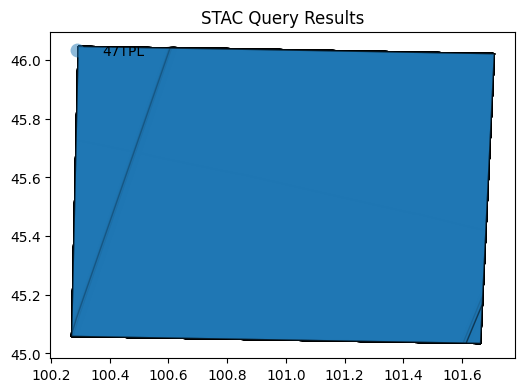

In [13]:
fig = gdf.plot(
    "granule",
    edgecolor="black",
    categorical=True,
    aspect="equal",
    alpha=0.5,
    figsize=(6, 12),
    legend=True,
    legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
)
_ = fig.set_title("STAC Query Results")

In [18]:
import planetary_computer
import pystac
import pystac_client
import json
raw_item: pystac.Item = 'st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D'
item: pystac.Item = planetary_computer.sign(raw_item)

In [10]:
planetary_computer.sign(raw_item)

'st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D'

In [19]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=planetary_computer.sign_inplace,
)

In [20]:
da

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 5, band: 2, y: 1001, x: 944)> Size: 38MB
dask.array<transpose, shape=(5, 2, 1001, 944), dtype=float32, chunksize=(1, 1, 1001, 944), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 8kB 5.012e+06 5.012e+06 ... 5.002e+06 5.002e+06
  * x            (x) float64 8kB 6.349e+05 6.349e+05 ... 6.443e+05 6.443e+05
  * time         (time) datetime64[ns] 40B 2021-01-02T23:24:55.259722 ... 202...
    spatial_ref  int64 8B 0
  * band         (band) <U2 16B 'vv' 'vh'

In [21]:
planetary_computer.sign_inplace

<function planetary_computer.sas.sign_inplace(obj: Any) -> Any>

In [5]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [6]:
data = da.sel(band='rvi')

In [7]:
data

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 23, y: 1001, x: 944)> Size: 87MB
dask.array<getitem, shape=(23, 1001, 944), dtype=float32, chunksize=(1, 1001, 944), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 8kB 5.012e+06 5.012e+06 ... 5.002e+06 5.002e+06
  * x            (x) float64 8kB 6.349e+05 6.349e+05 ... 6.443e+05 6.443e+05
  * time         (time) datetime64[ns] 184B 2021-01-02T23:24:55.259722 ... 20...
    spatial_ref  int64 8B 0
    band         <U5 20B 'rvi'

Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/8/18/IW/DV/S1B_IW_GRDH_1SDV_20210818T232448_20210818T232513_028307_0360A6_723F/measurement/iw-vh.rtc.tiff:1
Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/8/18/IW/DV/S1B_IW_GRDH_1SDV_20210818T232448_20210818T232513_028307_0360A6_723F/measurement/iw-vv.rtc.tiff:1


RasterioIOError: HTTP response code: 404

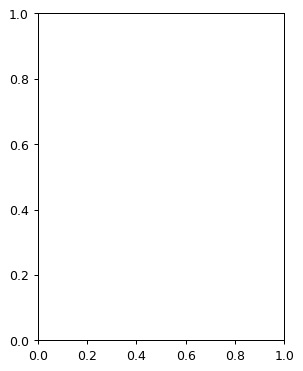

In [8]:
y_dim = data.sizes['y']
x_dim = data.sizes['x']
aspect_ratio = y_dim / x_dim

# Define base figure size and scale by aspect ratio
base_width = 10
base_height = 5
fig_width = base_width * min(1.5, max(0.5, aspect_ratio))  # limit within 0.5 and 1.5
fig_height = base_height * min(1.5, max(0.5, 1 / aspect_ratio))  # inverse ratio for height


fig = plt.figure(figsize=(fig_width, fig_height), dpi=90)
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 3], wspace=0.4)  # Adjust wspace to add horizontal spacing

# Plot the mean image
ax0 = plt.subplot(gs[0])
data.mean(dim="time").plot.imshow(vmin=0, vmax=1, ax=ax0)
ax0.set_title("Mean RVI")
ax0.tick_params(axis="x", rotation=45)



# Plot the timeseries
ax1 = plt.subplot(gs[1])
ax1.plot(data.time.to_numpy(), data.mean(dim=("x", "y")).to_numpy())
ax1.set_title("RVI Timeseries")
ax1.set_xlabel("Time")
ax1.set_ylabel("Pixel Values")
ax1.tick_params(axis="x", rotation=45)

# Adjust spacing around the entire figure and between subplots
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4)
plt.show()

## Planetary Computer test

In [2]:
!pip install planetary-computer

Defaulting to user installation because normal site-packages is not writeable
  Using cached planetary_computer-1.0.0-py3-none-any.whl (14 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 1.6 MB/s eta 0:00:0000:01
  Using cached python_dotenv-1.0.1-py3-none-any.whl (19 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.1 MB/s eta 0:00:00:00:01


In [1]:
import planetary_computer
import pystac_client
import pystac
from odc.stac import stac_load
from pystac_client import Client as pystacclient

In [16]:
raw_item: pystac.Item = "st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D"
item: pystac.Item = planetary_computer.sign(raw_item)

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [3]:
catalog

<Client id=microsoft-pc>